## EEG data in the dying human brain : defining stages & preprocessing


Notebook that : 
- load the baseline and the dying stages from Gang dataset 
- Annotate the stages from dictionnary defined in helpers
- Preprocess the dataset as done in Gang et al.,2023
- Define and save epochs 


---------------------------------------------------------------------

DATASET : 

- Original paper :  Surge of neurophysiological coupling and connectivity of gamma oscillations in the dying human brain (Xu et al.,2023) https://www.pnas.org/doi/abs/10.1073/pnas.2216268120

- Data available here : https://zenodo.org/records/7803212#.ZC3Cb-zML0q

- Supporting information available here : https://universityofsussex-my.sharepoint.com/:b:/r/personal/rb666_sussex_ac_uk/Documents/Projects/LZ%20NDE/Supplementary%20pnas.2216268120.sapp.pdf?csf=1&web=1&e=TY5ZjD

---------------------------------------------------------------------

@Code : Romy Beauté\
@Contact : r.beaut@sussex.ac.uk\
@Date : 22/02/24\
@Last modified : 05/03/24

In [1]:
# import streamlit as st
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

# matplotlib.use('Qt5Agg') to visualise online 

import mne
import numpy as np
import os
import sys
from helpers.helper4pipeline import read_EEG
from helpers.stages_infos import *
from helpers.preprocessing4pipeline import raw_preprocess, check_channels,save_preprocessed_data


### Load the 2 recordings : baseline and S2-end

In [2]:
# #####################  SELECT DATASET ####################################################################
DATASET_name = "Gang_2023"
patient = 1
############################################################################################################


DATASET_path = os.path.expanduser(f"~/projects/DATA/EEG/{DATASET_name}")
preprocessed_folder = os.path.join(DATASET_path, "preprocessed")
save_preproc = True

EEG_files = os.listdir(DATASET_path)
print(f"EEG files in {DATASET_name} : {[file for file in EEG_files if file.endswith('.edf')]}")

EEG_S1 = f"Pt{patient}_S1.edf" #correspond to stage S1 (comatose baseline)
EEG_S2_end = f"Pt{patient}_S2-end.edf" #correspond to stage S2 to the end of the recording (dying stages)
EEG_files = {'baseline': EEG_S1, 'end': EEG_S2_end}

stages_dict = timing_stages() #load the timing of the stages from helpers stage infos 

raw_eeg_baseline  = read_EEG(EEG_S1,DATASET_path,print_infos=False,plot_raw=False) #function from visualisation.py, read and visuale the EEG, does not do any preprocessing
raw_eeg_end = read_EEG(EEG_S2_end,DATASET_path,print_infos=False,plot_raw=False)



EEG files in Gang_2023 : ['Pt2_S1.edf', 'Pt1_S2-end.edf', 'Pt4_S2-end.edf', 'Pt4_S1.edf', 'Pt3_S2-end.edf', 'Pt3_S1.edf', 'Pt1_S1.edf', 'Pt2_S2-end.edf']
EEG file : Pt1_S1.edf
Extracting EDF parameters from /Users/rb666/projects/DATA/EEG/Gang_2023/Pt1_S1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 61439  =      0.000 ...   119.998 secs...
-----------------------------------------------------------------------------
Duration of Pt1_S1.edf recording: 119.998046875 seconds
No annotations in Pt1_S1.edf
-----------------------------------------------------------------------------
EEG file : Pt1_S2-end.edf
Extracting EDF parameters from /Users/rb666/projects/DATA/EEG/Gang_2023/Pt1_S2-end.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 275455  =      0.000 ...   537.998 secs...
-----------------------------------------------------------------------------
Duration of Pt1_S2-end.e

### Defining the Near Death stages and annotate data

No annotations found in the EEG file,adding the stages manually
Annotations added to the EEG data: ['S2' 'S3' 'S4' 'S5' 'S6' 'S7' 'S8' 'S9' 'S10' 'S11']
Used Annotations descriptions: ['S10', 'S11', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Using matplotlib as 2D backend.


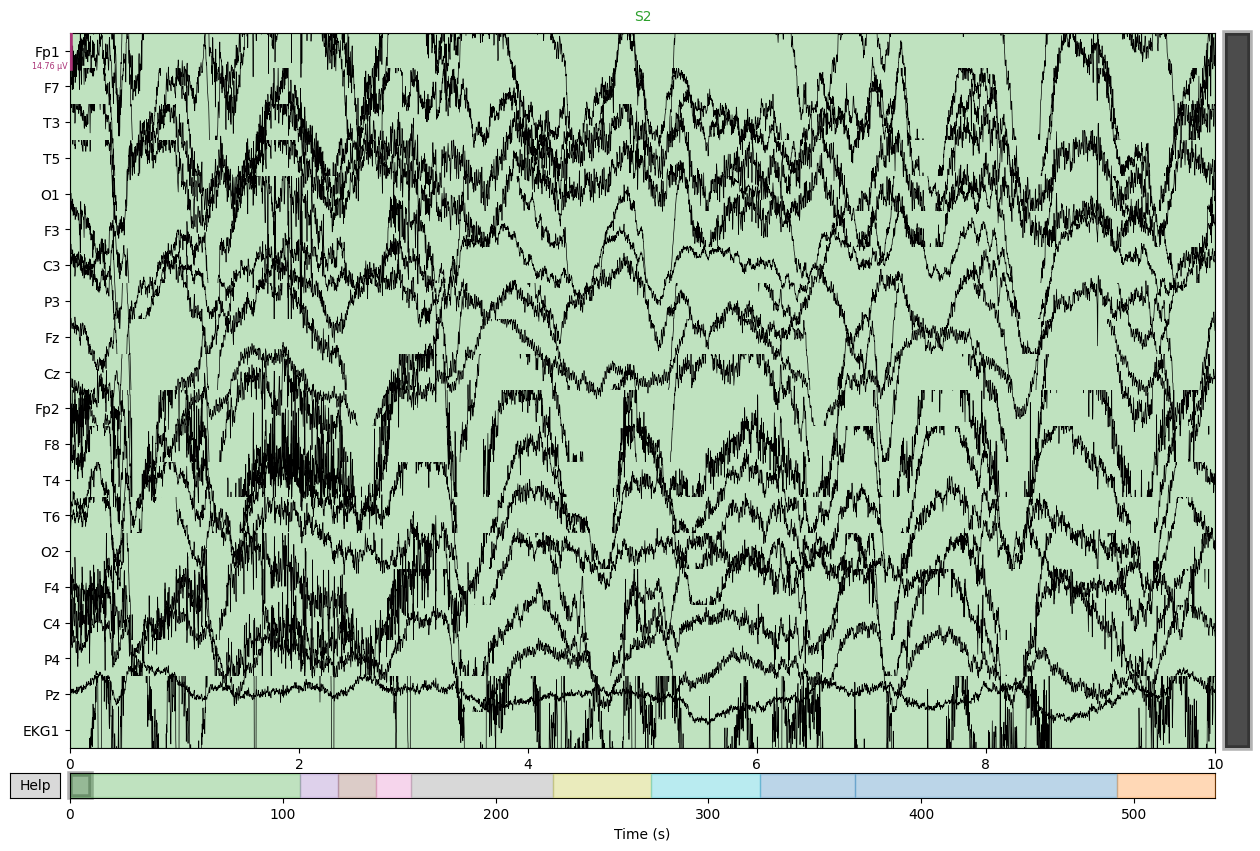

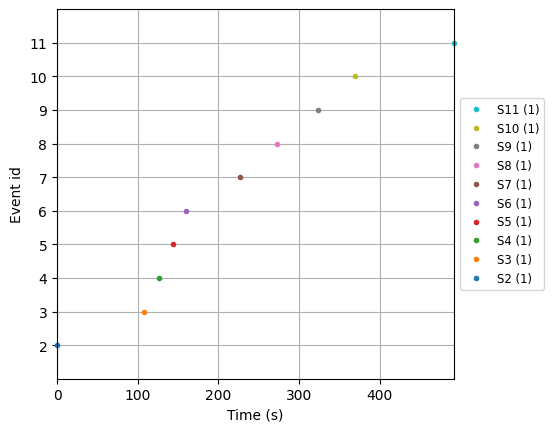

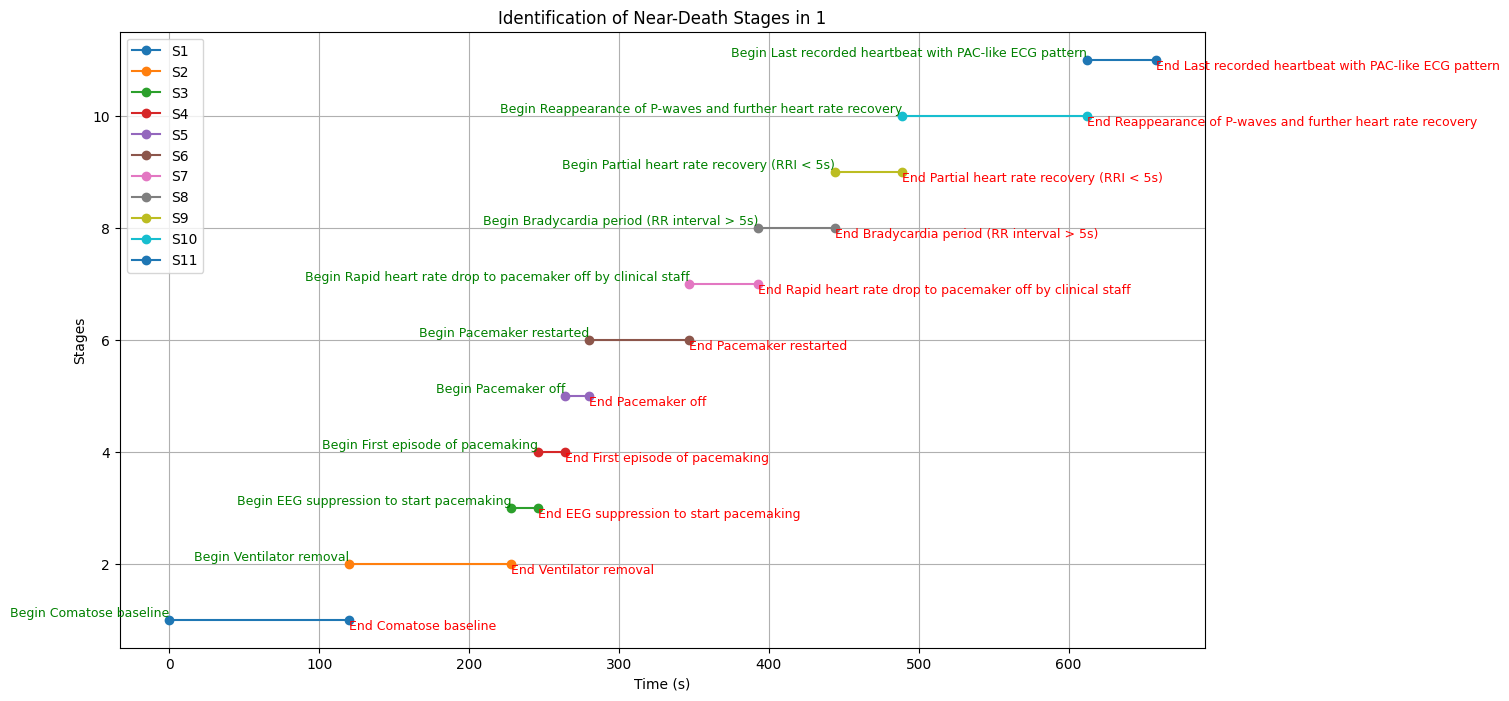

Stages metadata :   Stage  Onset  Duration
0    S2      0       108
1    S3    108        18
2    S4    126        18
3    S5    144        16
4    S6    160        67
5    S7    227        46
6    S8    273        51
7    S9    324        45
8   S10    369       123
9   S11    492        46


In [3]:
from helpers.stages_infos import annotate_stages


if not raw_eeg_end.annotations:
    print("No annotations found in the EEG file,adding the stages manually")
    raw_eeg_end, events, event_id, stages_metadata = annotate_stages(raw_eeg_end,patient) #add the stages to the EEG file
    print(f"Stages metadata : {stages_metadata}")

### Preprocessing starts 

In [4]:
# ##################### PREPROC PARAMS ####################################################################
baseline_correction = True
epoch_duration = 2.0
detrend = True
normalise = True
save_preproc = True
apply_hilbert = False
apply_ica = False
notch_filter = [60, 120, 180]
downsampling = 250
############################################################################################################

#preprocessing for baseline (Stage 1)
raw_EEG_baseline,raw_ECG_baseline = check_channels(raw_eeg_baseline)
eeg_baseline,epochs_baseline,preproc_params_baseline = raw_preprocess(raw_eeg_baseline,notchf=[60,120,180],downsampling=250,epoch_duration=2,detrend=detrend,normalise=normalise,apply_hilbert=apply_hilbert,apply_ica=apply_ica,plot_preproc=False)


#preprocessing for end (Stage 2-end)
raw_EEG_end,raw_ECG_end = check_channels(raw_eeg_end)
eeg_end,epochs_end,preproc_params_end = raw_preprocess(raw_eeg_end,notchf=[60,120,180],downsampling=250,epoch_duration=2,detrend=detrend,normalise=normalise,apply_hilbert=apply_hilbert,apply_ica=apply_ica,plot_preproc=False)


All channels :  ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz', 'EKG1']
Using channel EKG1 to identify heart beats.
Setting up band-pass filter from 5 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 5.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 4.75 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 35.25 Hz)
- Filter length: 5120 samples (10.000 s)

Number of ECG events detected : 165 (average pulse 82 / min.)
Selected EEG channels :  ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz']
No montage associated yet. Proceeding with renaming and setting new montage.
EEG channel type selected for re-referencing
Addi

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Number of ECG events detected : 474 (average pulse 52 / min.)
Selected EEG channels :  ['Fp1', 'F7', 'T3', 'T5', 'O1', 'F3', 'C3', 'P3', 'Fz', 'Cz', 'Fp2', 'F8', 'T4', 'T6', 'O2', 'F4', 'C4', 'P4', 'Pz']
No montage associated yet. Proceeding with renaming and setting new montage.
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Average reference projection applied.
-------------DATA INFOS-----------------
<Annotations | 10 segments: S10 (1), S11 (1), S2 (1), S3 (1), S4 (1), S5 ...>
Used Annotations descriptions: ['S10', 'S11', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
------------------------------------
----------PREPROCESSING 1 (ON CONTINUOUS DATA) ----------------
Filtering raw data in 1 contiguous se

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Created 2-second epochs without baseline correction: <Epochs |  268 events (all good), 0 – 2 s, baseline off, ~19.5 MB, data loaded,
 '1': 268>
Detrending applied.
Normalization applied.


### Add metadata for epochs to label them with corresp. stages

In [5]:
#Add METADATA for epochs_end
epochs_metadata = generate_epoch_metadata(epochs_end,patient,stages_metadata, epoch_duration=epoch_duration)

epochs_metadata.index = epochs_end.selection # Ensure metadata df's index matches epochs' index
epochs_end.metadata = epochs_metadata # assign the df as metadata attribute of the epochs
print(epochs_end.metadata.head())


#Save preprocessed and epoches data
preprocessed_data = [eeg_baseline,epochs_baseline,eeg_end,epochs_end] #save preprocessed data 
preproc_params_list = [preproc_params_baseline, preproc_params_end]

Generating metadata (pt 1): associate 10 stages with 268 epochs
Adding metadata with 3 columns
   Epoch Number  Onset Stage
0             1    0.0    S2
1             2    2.0    S2
2             3    4.0    S2
3             4    6.0    S2
4             5    8.0    S2


### Visualise epoched and preprocessed baseline

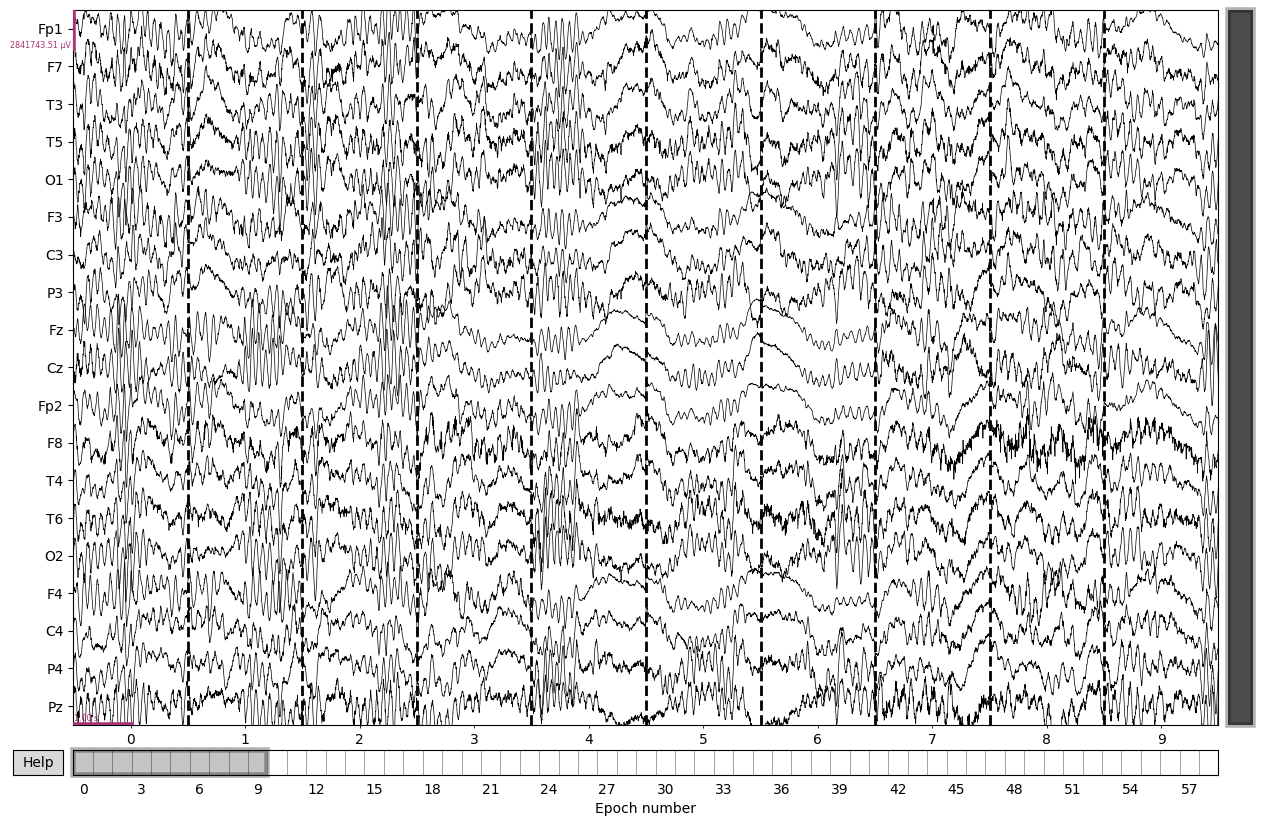

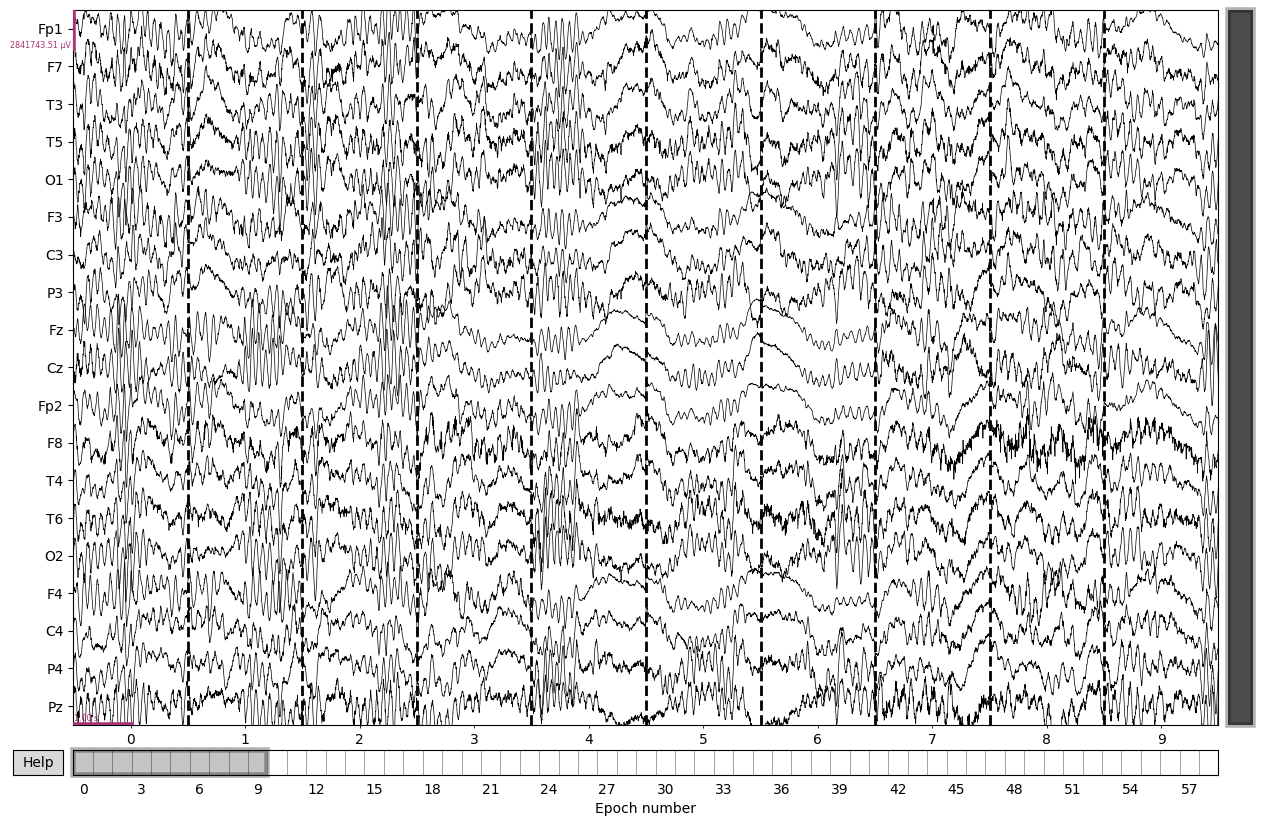

In [6]:
epochs_baseline.plot(n_epochs=10, n_channels=19, picks='eeg',scalings='auto') #plot the first 10 epochs of the baseline stages

### Visualise epoched and preprocessed S2-end staged

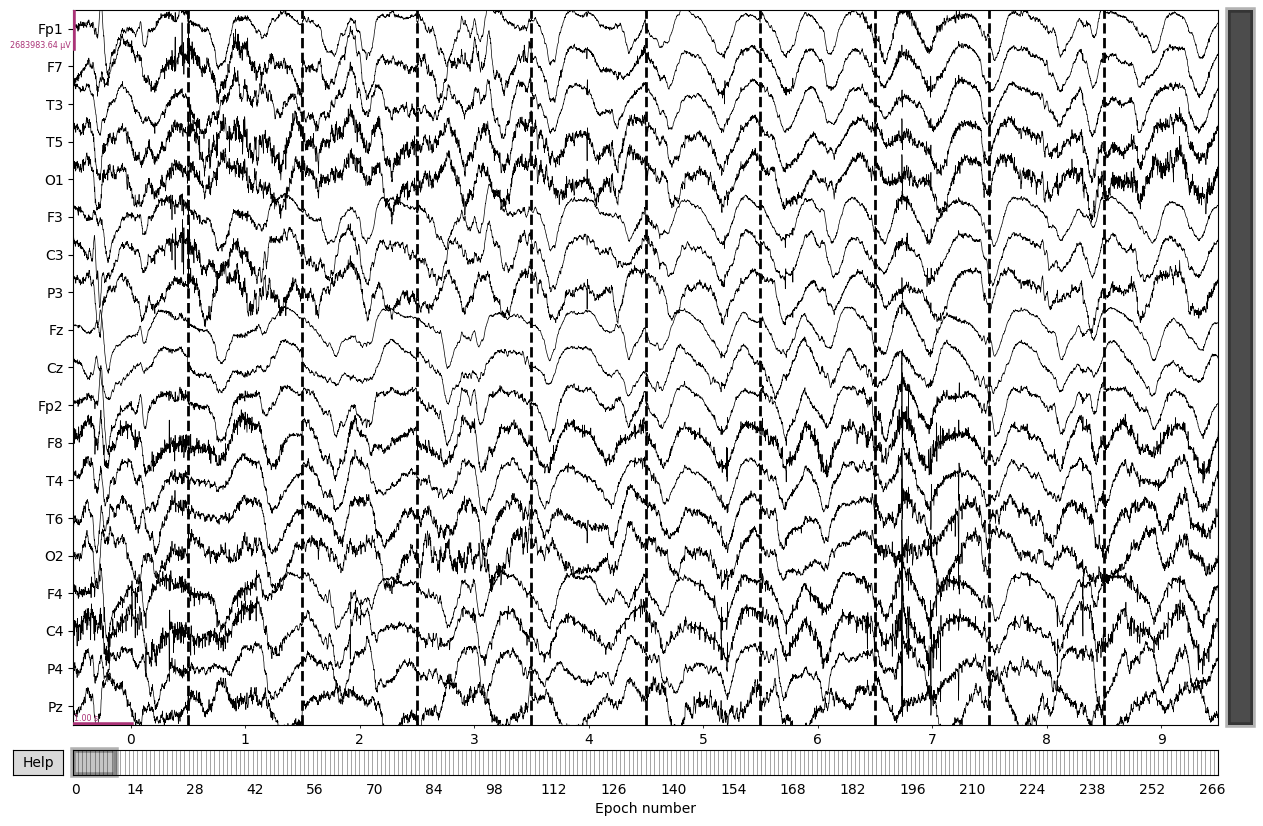

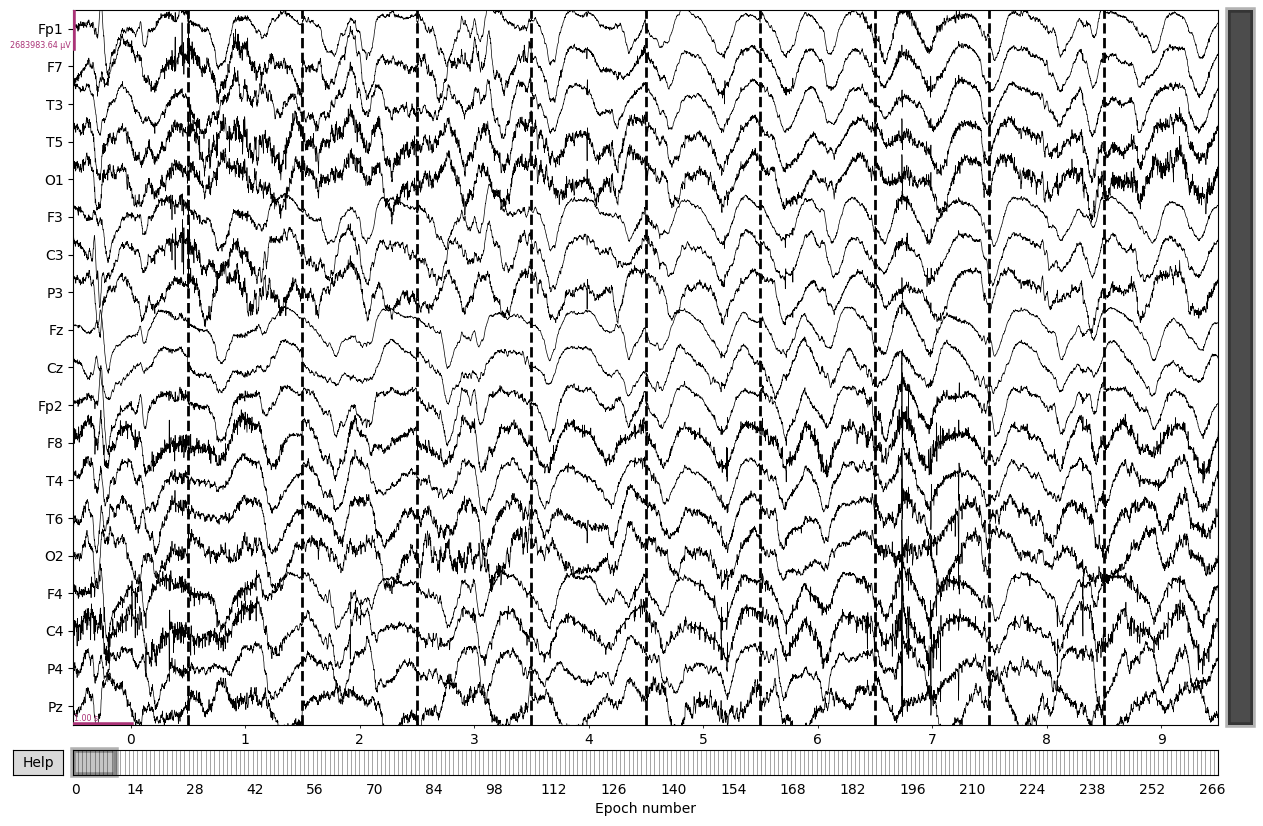

In [7]:
epochs_end.plot(n_epochs=10, n_channels=19, picks='eeg',scalings='auto') #plot the first 10 epochs of the dying stages
# print(epochs_end.annotations[0]['description']) #check if annotations well applied on epochs

In [8]:
#save preprocessing file and parameters of preprocessed_data

if save_preproc:
    save_preprocessed_data(preprocessed_data, preprocessed_folder, EEG_files, preproc_params_list)


Preprocessed data will be saved in the following folder:  /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed
Saving preprocessed data to /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_baseline_preprocessed_eeg.fif
Overwriting existing file.
Writing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_baseline_preprocessed_eeg.fif
Closing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_baseline_preprocessed_eeg.fif
[done]
Saving preprocessed data to /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_baseline_preprocessed_epo.fif
Overwriting existing file.
Overwriting existing file.
Saving preprocessed data to /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S2-end_end_preprocessed_eeg.fif
Overwriting existing file.
Writing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S2-end_end_preprocessed_eeg.fif
Closing /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S2-end_end_preprocessed_eeg.fif
[done]
Saving preproces